In [32]:
# 1. Total de vendas por loja - Agrupar por loja e somar o valor total vendido
# 2. Evolução mensal de vendas -  Identificar sazonalidades e picos mensais.
# 3. Agrupar por mês e somar vendas
# 4. Produtos mais vendidos (por volume) Objetivo: saber o que mais sai no caixa.
# 5. Comparação entre categorias. Objetivo: analisar quais categorias são mais lucrativas.

# 6. Comparação entre lojas por categoria. Objetivo: avaliar se há especialização ou foco
# diferente entre as lojas, com base nas categorias que mais vendem.

# 7. Plotar como gráfico de barras empilhadas

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('vendas_novo.xlsx')

In [34]:
# 1. Total de vendas por loja - Agrupar por loja e somar o valor total vendido
total = df.groupby('loja', as_index=False)['valor_venda'].sum()
print(total)

          loja  valor_venda
0  Chuva clara    167110.14
1    Porto sol    148059.25
2  Vento norte    160780.08
3    Vila neve    144611.09


C:\Users\53282601808\AppData\Local\Temp\ipykernel_9156\864164053.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  soma_mensal = df['valor_venda'].resample('M').sum()


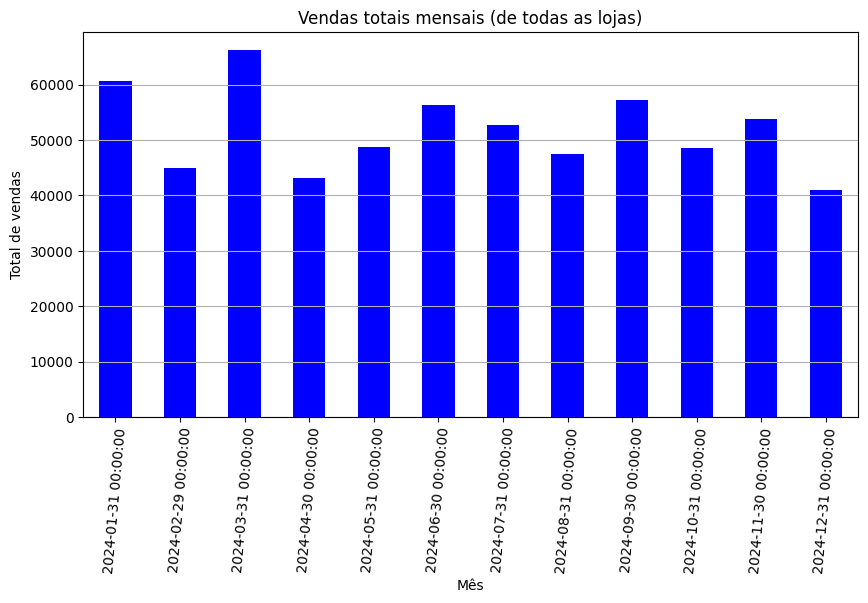

In [35]:
# 2. Evolução mensal de vendas -  Identificar sazonalidades e picos mensais
df.set_index('data', inplace=True) #Define a coluna 'data' como índice

#Somando as vendas mensais
soma_mensal = df['valor_venda'].resample('M').sum()

#Grafico
plt.figure(figsize=(10,5))
soma_mensal.plot(kind='bar', color='blue')
plt.title('Vendas totais mensais (de todas as lojas)')
plt.xlabel('Mês')
plt.ylabel('Total de vendas')
plt.xticks(rotation=85)
plt.grid(axis='y')
plt.show()


In [36]:
# 3. Agrupar por mês e somar vendas
# Resolução deste está no exercício anterior

print(soma_mensal)

data
2024-01-31    60691.71
2024-02-29    44847.58
2024-03-31    66190.62
2024-04-30    43056.45
2024-05-31    48735.05
2024-06-30    56312.80
2024-07-31    52659.94
2024-08-31    47412.70
2024-09-30    57258.88
2024-10-31    48616.57
2024-11-30    53871.05
2024-12-31    40907.21
Freq: ME, Name: valor_venda, dtype: float64


In [37]:
# 4. Produtos mais vendidos (por volume) Objetivo: saber o que mais sai no caixa.

volume = df.groupby('produto', as_index=False)['quantidade'].sum()
print(volume)
print()


            produto  quantidade
0         Aquecedor         215
1   Ar-condicionado         153
2    Blusa infantil         181
3             Calça         163
4          Camiseta         130
5            Casaco         156
6      Guarda-chuva         253
7         Lancheira         191
8     Manta térmica         215
9           Mochila         192
10   Protetor solar         260
11       Ventilador         165
12          Vestido         148



In [38]:
# 5. Comparação entre categorias. Objetivo: analisar quais categorias são mais lucrativas.

lucro = df.groupby('categoria', as_index=False)['valor_venda'].sum()
print(lucro)

          categoria  valor_venda
0  Eletrodomesticos    125584.66
1          Infantil    157641.01
2            Roupas    161911.43
3           Sazonal    175423.46


loja              Chuva clara  Porto sol  Vento norte  Vila neve
categoria                                                       
Eletrodomesticos     27670.37   30426.94     31290.97   36196.38
Infantil             36123.45   32562.67     38057.35   50897.54
Roupas               58699.26   31687.21     47861.56   23663.40
Sazonal              44617.06   53382.43     43570.20   33853.77


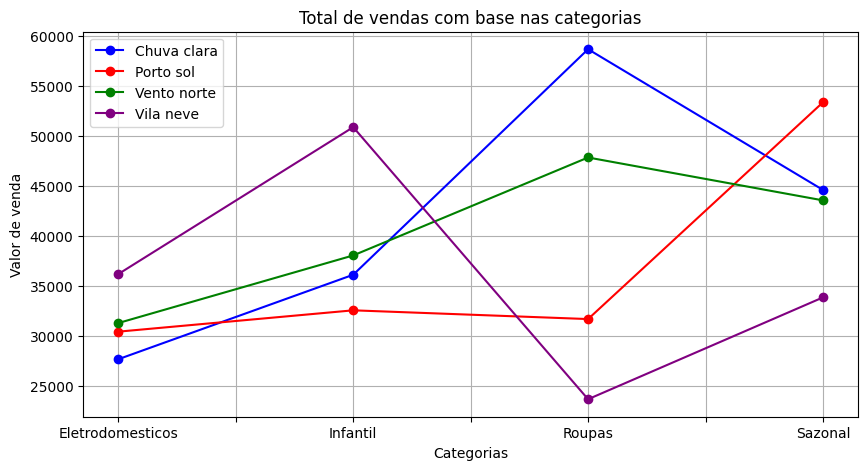

In [39]:
# 6. Comparação entre lojas por categoria. Objetivo: avaliar se há especialização ou foco
# diferente entre as lojas, com base nas categorias que mais vendem.

venda_cat = df.groupby(['categoria', 'loja'])['valor_venda'].sum().unstack()
print(venda_cat)

plt.figure(figsize=(10,5))
venda_cat['Chuva clara'].plot(marker='o', linestyle='-', color='blue', label='Chuva clara')
venda_cat['Porto sol'].plot(marker='o', linestyle='-', color='red', label='Porto sol')
venda_cat['Vento norte'].plot(marker='o', linestyle='-', color='green', label='Vento norte')
venda_cat['Vila neve'].plot(marker='o', linestyle='-', color='purple', label='Vila neve')

plt.title('Total de vendas com base nas categorias')
plt.xlabel('Categorias')
plt.ylabel('Valor de venda')
plt.grid(True)
plt.legend()
plt.show()

loja              Chuva clara  Porto sol  Vento norte  Vila neve
categoria                                                       
Eletrodomesticos     27670.37   30426.94     31290.97   36196.38
Infantil             36123.45   32562.67     38057.35   50897.54
Roupas               58699.26   31687.21     47861.56   23663.40
Sazonal              44617.06   53382.43     43570.20   33853.77


<Figure size 1000x500 with 0 Axes>

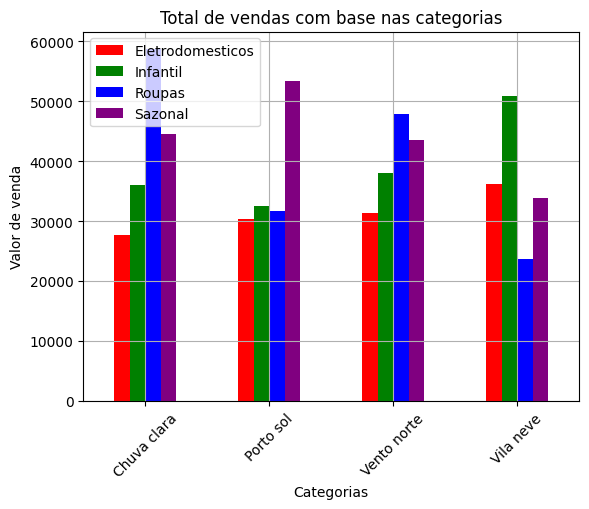

In [40]:
# 6. Comparação entre lojas por categoria. Objetivo: avaliar se há especialização ou foco
# diferente entre as lojas, com base nas categorias que mais vendem.
venda_cat2 = df.groupby(['loja', 'categoria'])['valor_venda'].sum().unstack()
print(venda_cat)

plt.figure(figsize=(10,5))
venda_cat2.plot(color=['red', 'green', 'blue', 'purple'], kind='bar')

plt.title('Total de vendas com base nas categorias')
plt.xlabel('Categorias')
plt.ylabel('Valor de venda')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()